In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Retrieving the dataset
data = pd.read_csv('../backend/app/data/players_2024.csv')
data.head()

,player_display_name,position,fantasy_points_ppr,recent_team,games_played
0,Lamar Jackson,QB,430.4,BAL,17
1,Ja'Marr Chase,WR,403.0,CIN,17
2,Joe Burrow,QB,372.8,CIN,17
3,Josh Allen,QB,372.3,BUF,16
4,Baker Mayfield,QB,365.8,TB,17


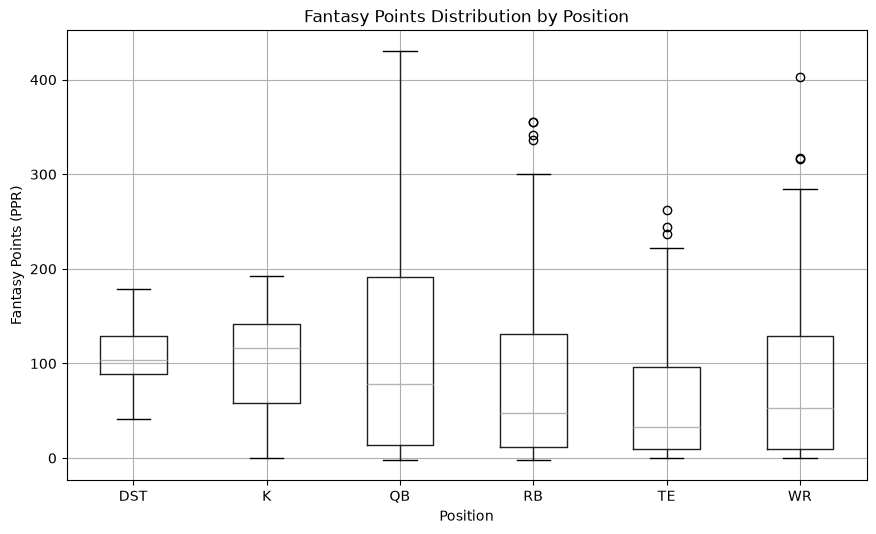

'\nEach position has a reasonable spread (no flat lines)\nSome positions have outliers (TE/WR), which just means some players played way above average\nDST and K have smaller plots (they score fewwer points than skill players)\n'

In [3]:
# Points distribution by position
data.boxplot(column='fantasy_points_ppr', by='position', figsize=(10,6))
plt.title('Fantasy Points Distribution by Position')
plt.suptitle('')
plt.ylabel('Fantasy Points (PPR)')
plt.xlabel('Position')
plt.savefig('figures/points_by_position.png', dpi=150, bbox_inches='tight')
plt.show()
"""
Each position has a reasonable spread (no flat lines)
Some positions have outliers (TE/WR), which just means some players played way above average
DST and K have smaller plots (they score fewwer points than skill players)
"""

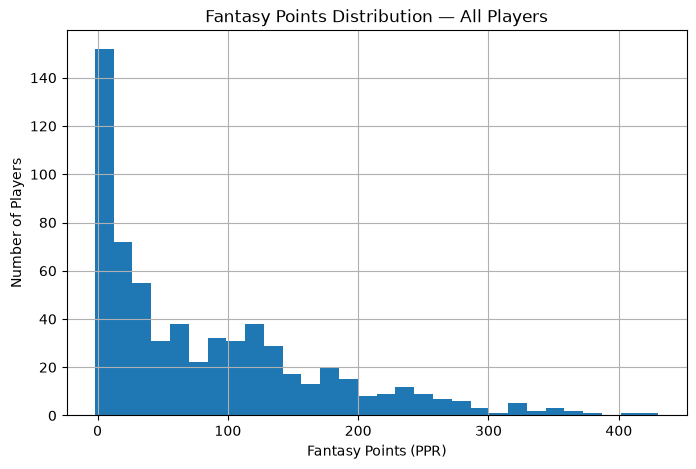

'\nRight-skewed distribution\nA big pile of players clustered at lower point totals\nTaper off into a long tail of few exceptional players\nThere is a huge amount of players near 0, which means a good amount of players played more than 4 games and scored nothing\n'

In [4]:
# Overall points distribution
data['fantasy_points_ppr'].hist(bins=30, figsize=(8, 5))
plt.title('Fantasy Points Distribution — All Players')
plt.xlabel('Fantasy Points (PPR)')
plt.ylabel('Number of Players')
plt.savefig('figures/points_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
"""
Right-skewed distribution
A big pile of players clustered at lower point totals
Taper off into a long tail of few exceptional players
There is a huge amount of players near 0, which means a good amount of players played more than 4 games and scored nothing
"""

In [5]:
# Team roster's distribution
team_position_counts = data.groupby(["recent_team", "position"]).size().unstack(fill_value=0)
team_position_counts

position,DST,K,QB,RB,TE,WR
recent_team,,,,,,
ARI,1,2,2,6,3,5
ATL,1,2,2,3,3,6
BAL,1,1,2,4,3,7
BUF,1,1,3,3,4,6
CAR,1,1,2,5,6,7
CHI,1,1,2,5,3,6
CIN,1,2,2,3,5,7
CLE,1,1,4,5,5,10
DAL,1,1,3,4,3,6


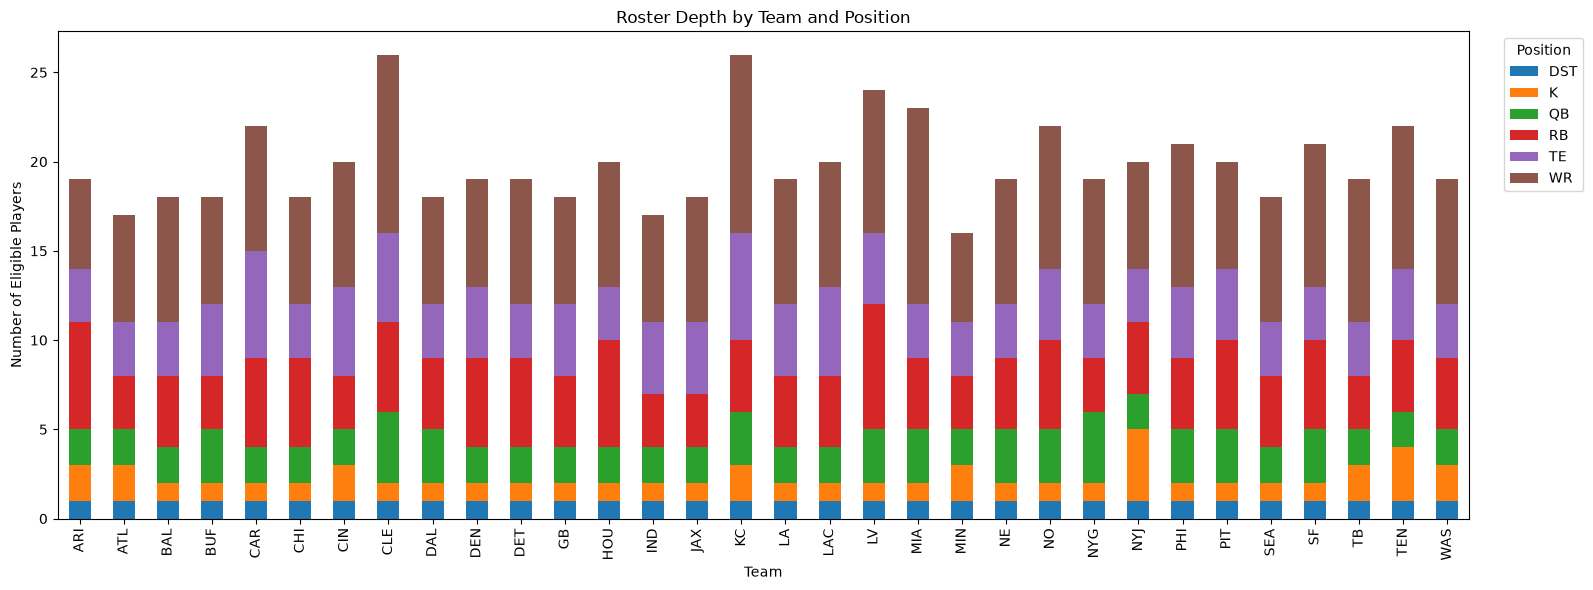

'\nMost plots are around the same level when it comes to the number of total players\nLAC has the most players\nCHI has the least players\n'

In [6]:
# Team Depth Chart
team_position_counts.plot(kind='bar', stacked=True, figsize=(16, 6))
plt.title('Roster Depth by Team and Position')
plt.ylabel('Number of Eligible Players')
plt.xlabel('Team')
plt.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figures/team_position_depth.png', dpi=150, bbox_inches='tight')
plt.show()
"""
Most plots are around the same level when it comes to the number of total players
KC and CLE have around the most players
MIN has the least players
"""